In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from streaming import (
    CountMinSketch,
    DGIM,
    estadisticas_por_ventana,
    metricas_globales_por_ventana,
    cargar_json_lineas_robusto,
)

# Paleta consistente con el EDA
PALETTE   = "#7F77DD"
ACCENT    = "#1D9E75"
OUTLIER_C = "#D85A30"
BG        = "#F8F8FC"
GRID_C    = "#E8E8F0"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.grid":         True,
    "grid.color":        GRID_C,
    "grid.linewidth":    0.6,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "font.family":       "sans-serif",
})

In [2]:
try:
    df_reviews
except NameError:
    df_reviews = cargar_json_lineas_robusto("review_sample.json")
    df_reviews["text_length"] = df_reviews["text"].str.len()
if not pd.api.types.is_datetime64_any_dtype(df_reviews["date"]):
    df_reviews["date"] = pd.to_datetime(df_reviews["date"])

if "year" not in df_reviews.columns:
    df_reviews["year"] = df_reviews["date"].dt.year

if "text_length" not in df_reviews.columns:
    df_reviews["text_length"] = df_reviews["text"].str.len()
#orden cronológico
stream_df = df_reviews.sort_values("date").reset_index(drop=True)

stream_df["hour"]  = stream_df["date"].dt.hour
stream_df["dow"]   = stream_df["date"].dt.dayofweek   # 0 = lunes
stream_df["month"] = stream_df["date"].dt.month

print(f"Total de reseñas en el stream: {len(stream_df):,}")
print(f"Rango temporal: {stream_df['date'].min()} → {stream_df['date'].max()}")
stream_df[["review_id", "business_id", "user_id", "date", "stars", "useful", "funny", "cool"]].head()

 Advertencia: se saltaron 1 líneas corruptas de 27541 en review_sample.json.
Total de reseñas en el stream: 27,540
Rango temporal: 2005-04-10 23:10:56 → 2022-01-19 18:57:45


,review_id,business_id,user_id,date,stars,useful,funny,cool
0,PQ1xH9CmH2mdGZqIJsPFPA,lS1dmSXpAtQqT04eRm9kiA,ZftKc54UnKJSbuzyEg4SjA,2005-04-10 23:10:56,4.0,0,0,0
1,nS9L0OSxY5C8eXwBXRhEmA,6JaHpWSKuJgTQTmxHxPe3A,-qoyKSF2G3PkR_7XNoJfpQ,2005-05-18 15:47:24,4.0,3,0,0
2,VTwxOYGVlG3TNx2gMuTbxg,3XirYkP9PJvVXIEDPNNXLA,3xX-Et9I4Bi4wdRPWJkAFg,2005-12-29 16:53:21,5.0,0,1,2
3,XMJJS16B16EDdE1bcac_sg,-V0vIgo6196MDn_x3ZaYmA,NxcJCKeTLNVl-xRP7rpDhw,2006-01-01 00:55:37,4.0,1,0,2
4,FyCIUGTG2rZ91Kd5WOT-dA,AfassS1QI0DHsqwuof9-lA,GitE04dW0jYxH5LplUTDBA,2006-01-31 23:59:44,4.0,2,1,2


---
## 1. Ventanas Deslizantes (Sliding Windows) — Estadísticas y métricas

**Objetivo:** dividir el stream de reseñas en ventanas de tiempo de tamaño fijo (1 hora, 4 horas, 1 día) y calcular, para cada ventana, las estadísticas requeridas (`count`, `sum`, `average`) más un panel extendido de **métricas por ventana** (volumen, calidad percibida, diversidad de negocios/usuarios activos).

Conceptualmente, esto equivale a un procesador de streams que mantiene acumuladores (`count`, `sum`, `sum_sq`, `set` aproximado de ids vistos) por ventana activa y los "emite" al cerrarse la ventana — memoria `O(1)` por ventana, sin guardar cada evento.

In [3]:
win_1h = estadisticas_por_ventana(stream_df, "1h")
win_4h = estadisticas_por_ventana(stream_df, "4h")
win_1d = estadisticas_por_ventana(stream_df, "1D")

print("Ventanas de 1 hora — resumen estadístico:")
display(win_1h.describe().round(2))

print("\nVentanas de 4 horas — resumen estadístico:")
display(win_4h.describe().round(2))

print("\nVentanas de 1 día — resumen estadístico:")
display(win_1d.describe().round(2))

Ventanas de 1 hora — resumen estadístico:


,count,sum,average,std,min,max
count,147068.00,147068.00,22678.00,4079.00,22678.00,22678.00
mean,0.19,0.71,3.77,1.10,3.62,3.91
std,0.48,1.92,1.38,0.97,1.50,1.40
min,0.00,0.00,1.00,0.00,1.00,1.00
25%,0.00,0.00,3.00,0.00,2.00,3.00
50%,0.00,0.00,4.00,0.71,4.00,5.00
75%,0.00,0.00,5.00,2.08,5.00,5.00
max,6.00,25.00,5.00,2.83,5.00,5.00



Ventanas de 4 horas — resumen estadístico:


,count,sum,average,std,min,max
count,36768.00,36768.00,14709.00,7083.00,14709.00,14709.00
mean,0.75,2.82,3.75,1.17,3.23,4.19
std,1.19,4.67,1.22,0.87,1.56,1.25
min,0.00,0.00,1.00,0.00,1.00,1.00
25%,0.00,0.00,3.00,0.58,2.00,4.00
50%,0.00,0.00,4.00,1.15,4.00,5.00
75%,1.00,5.00,5.00,1.91,5.00,5.00
max,11.00,42.00,5.00,2.83,5.00,5.00



Ventanas de 1 día — resumen estadístico:


,count,sum,average,std,min,max
count,6129.00,6129.00,4740.00,4103.00,4740.00,4740.00
mean,4.49,16.95,3.75,1.33,2.13,4.72
std,4.21,16.30,0.76,0.58,1.37,0.72
min,0.00,0.00,1.00,0.00,1.00,1.00
25%,1.00,3.00,3.33,0.97,1.00,5.00
50%,4.00,13.00,3.86,1.42,1.00,5.00
75%,7.00,27.00,4.23,1.73,3.00,5.00
max,23.00,91.00,5.00,2.83,5.00,5.00


In [23]:
def comparar_ventanas(ventanas: dict, metric: str = "average",
                       title: str | None = None, figsize=(13, 8)):
    import matplotlib.pyplot as plt
    import seaborn as sns

    colors = ["#7F77DD", "#1D9E75", "#D85A30", "#3F6FAE", "#AE3F6F"]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.4, 1])

    ax_ts   = fig.add_subplot(gs[0, :])
    ax_box  = fig.add_subplot(gs[1, 0])
    ax_tab  = fig.add_subplot(gs[1, 1])
    ax_tab.axis("off")

    resumen_rows = []
    for i, (label, win) in enumerate(ventanas.items()):
        serie = win[metric].dropna()
        color = colors[i % len(colors)]

        ax_ts.plot(serie.index, serie.values, label=f"ventana {label}",
                   color=color, linewidth=1.0, alpha=0.85)


        resumen_rows.append({
            "ventana": label,
            "n_ventanas": len(serie),
            "mean": serie.mean(),
            "std": serie.std(),
            "min": serie.min(),
            "max": serie.max(),
            "cv (%)": (serie.std() / serie.mean() * 100) if serie.mean() != 0 else np.nan,
        })

    ax_ts.set_title(f"Comparación de '{metric}' entre tamaños de ventana")
    ax_ts.set_xlabel("Fecha")
    ax_ts.set_ylabel(metric)
    ax_ts.legend(fontsize=9)

    box_data = [win[metric].dropna().values for win in ventanas.values()]
    bp = ax_box.boxplot(box_data, labels=list(ventanas.keys()), patch_artist=True,
                         showfliers=False)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)
    ax_box.set_title(f"Distribución de '{metric}' por tamaño de ventana")
    ax_box.set_xlabel("Tamaño de ventana")
    ax_box.set_ylabel(metric)

    df_resumen = pd.DataFrame(resumen_rows).set_index("ventana").round(3)
    tabla = ax_tab.table(
        cellText := df_resumen.reset_index().values,
        colLabels=df_resumen.reset_index().columns,
        loc="center", cellLoc="center"
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9)
    tabla.scale(1, 1.6)
    ax_tab.set_title("Resumen estadístico por ventana", pad=20)

    if title:
        fig.suptitle(title, fontsize=14, fontweight="600", y=1.02)

    plt.tight_layout()
    return fig, (ax_ts, ax_box, ax_tab), df_resumen

/tmp/ipykernel_1970/146265646.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(box_data, labels=list(ventanas.keys()), patch_artist=True,


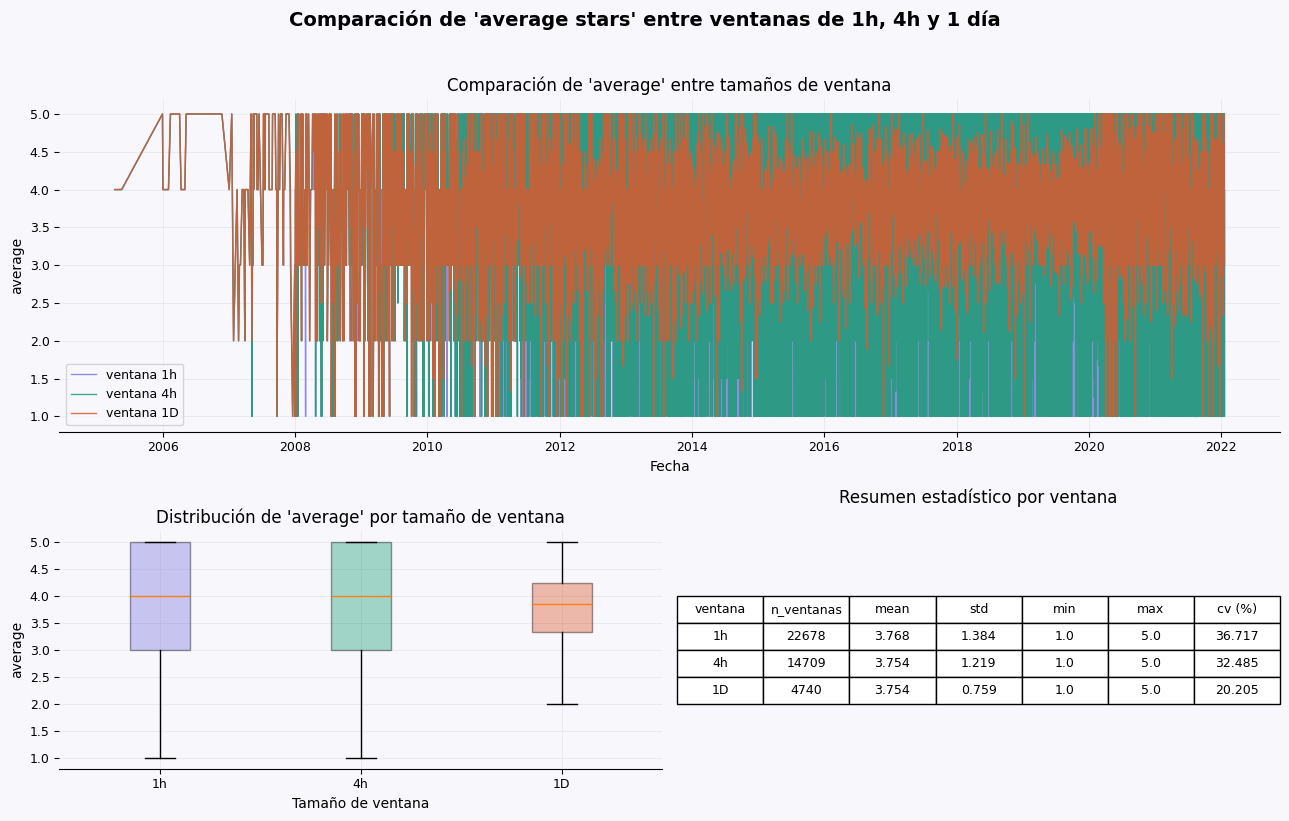

,n_ventanas,mean,std,min,max,cv (%)
ventana,,,,,,
1h,22678,3.768,1.384,1.0,5.0,36.717
4h,14709,3.754,1.219,1.0,5.0,32.485
1D,4740,3.754,0.759,1.0,5.0,20.205


In [24]:
ventanas_dict = {"1h": win_1h, "4h": win_4h, "1D": win_1d}

fig, axes, df_resumen = comparar_ventanas(
    ventanas_dict,
    metric="average",
    title="Comparación de 'average stars' entre ventanas de 1h, 4h y 1 día"
)
plt.show()
display(df_resumen)

/tmp/ipykernel_1970/146265646.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(box_data, labels=list(ventanas.keys()), patch_artist=True,


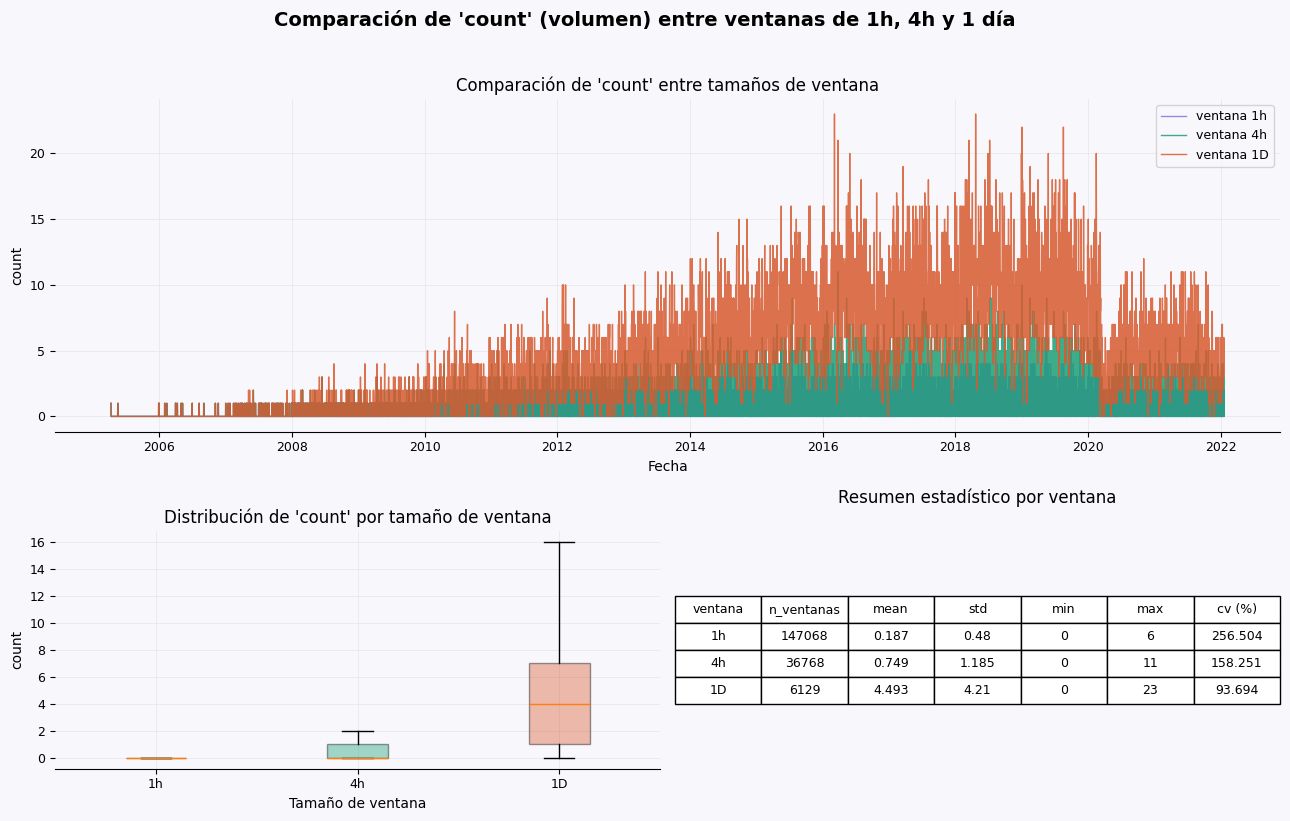

,n_ventanas,mean,std,min,max,cv (%)
ventana,,,,,,
1h,147068,0.187,0.480,0,6,256.504
4h,36768,0.749,1.185,0,11,158.251
1D,6129,4.493,4.210,0,23,93.694


In [25]:
fig, axes, df_resumen_count = comparar_ventanas(
    ventanas_dict,
    metric="count",
    title="Comparación de 'count' (volumen) entre ventanas de 1h, 4h y 1 día"
)
plt.show()
display(df_resumen_count)

In [4]:
print("Primeras ventanas de 1 día (count, sum, average, std, min, max de 'stars'):")
display(win_1d.head(10).round(2))

Primeras ventanas de 1 día (count, sum, average, std, min, max de 'stars'):


,count,sum,average,std,min,max
date,,,,,,
2005-04-10,1,4.0,4.0,NaN,4.0,4.0
2005-04-11,0,0.0,NaN,NaN,NaN,NaN
2005-04-12,0,0.0,NaN,NaN,NaN,NaN
2005-04-13,0,0.0,NaN,NaN,NaN,NaN
2005-04-14,0,0.0,NaN,NaN,NaN,NaN
2005-04-15,0,0.0,NaN,NaN,NaN,NaN
2005-04-16,0,0.0,NaN,NaN,NaN,NaN
2005-04-17,0,0.0,NaN,NaN,NaN,NaN
2005-04-18,0,0.0,NaN,NaN,NaN,NaN


### 1.1 Panel de métricas por ventana (1 día)

Además de `count/sum/average`, calculamos un panel más rico de métricas por ventana:

- `n_reviews`: volumen (tendencia de popularidad)
- `avg_stars`: calidad percibida promedio
- `pct_useful`: fracción de reseñas marcadas como útiles
- `avg_text_length`: longitud promedio del texto
- `n_business_unicos` / `n_users_unicos`: diversidad de actores activos por ventana

In [5]:
metricas_1d = metricas_globales_por_ventana(stream_df, "1D")
display(metricas_1d.head(10).round(2))
display(metricas_1d.describe().round(2))

,n_reviews,avg_stars,sum_useful,pct_useful,avg_text_length,n_business_unicos,n_users_unicos
date,,,,,,,
2005-04-10,1,4.0,0,0.0,567.0,1,1
2005-04-11,0,NaN,0,NaN,NaN,0,0
2005-04-12,0,NaN,0,NaN,NaN,0,0
2005-04-13,0,NaN,0,NaN,NaN,0,0
2005-04-14,0,NaN,0,NaN,NaN,0,0
2005-04-15,0,NaN,0,NaN,NaN,0,0
2005-04-16,0,NaN,0,NaN,NaN,0,0
2005-04-17,0,NaN,0,NaN,NaN,0,0
2005-04-18,0,NaN,0,NaN,NaN,0,0


,n_reviews,avg_stars,sum_useful,pct_useful,avg_text_length,n_business_unicos,n_users_unicos
count,6129.00,4740.00,6129.00,4740.00,4740.00,6129.00,6129.00
mean,4.49,3.75,5.15,0.49,602.22,4.48,4.48
std,4.21,0.76,7.22,0.29,315.86,4.19,4.20
min,0.00,1.00,0.00,0.00,29.00,0.00,0.00
25%,1.00,3.33,0.00,0.29,406.02,1.00,1.00
50%,4.00,3.86,3.00,0.50,533.07,4.00,4.00
75%,7.00,4.23,7.00,0.67,717.03,7.00,7.00
max,23.00,5.00,138.00,1.00,3013.00,23.00,23.00


### 1.2 Evolución temporal: volumen, calidad y diversidad (dashboard)

Dashboard de 4 paneles que muestran la evolución día a día de todo el panel de métricas — equivalente a lo que vería un analista en un tablero de monitoreo en tiempo real.

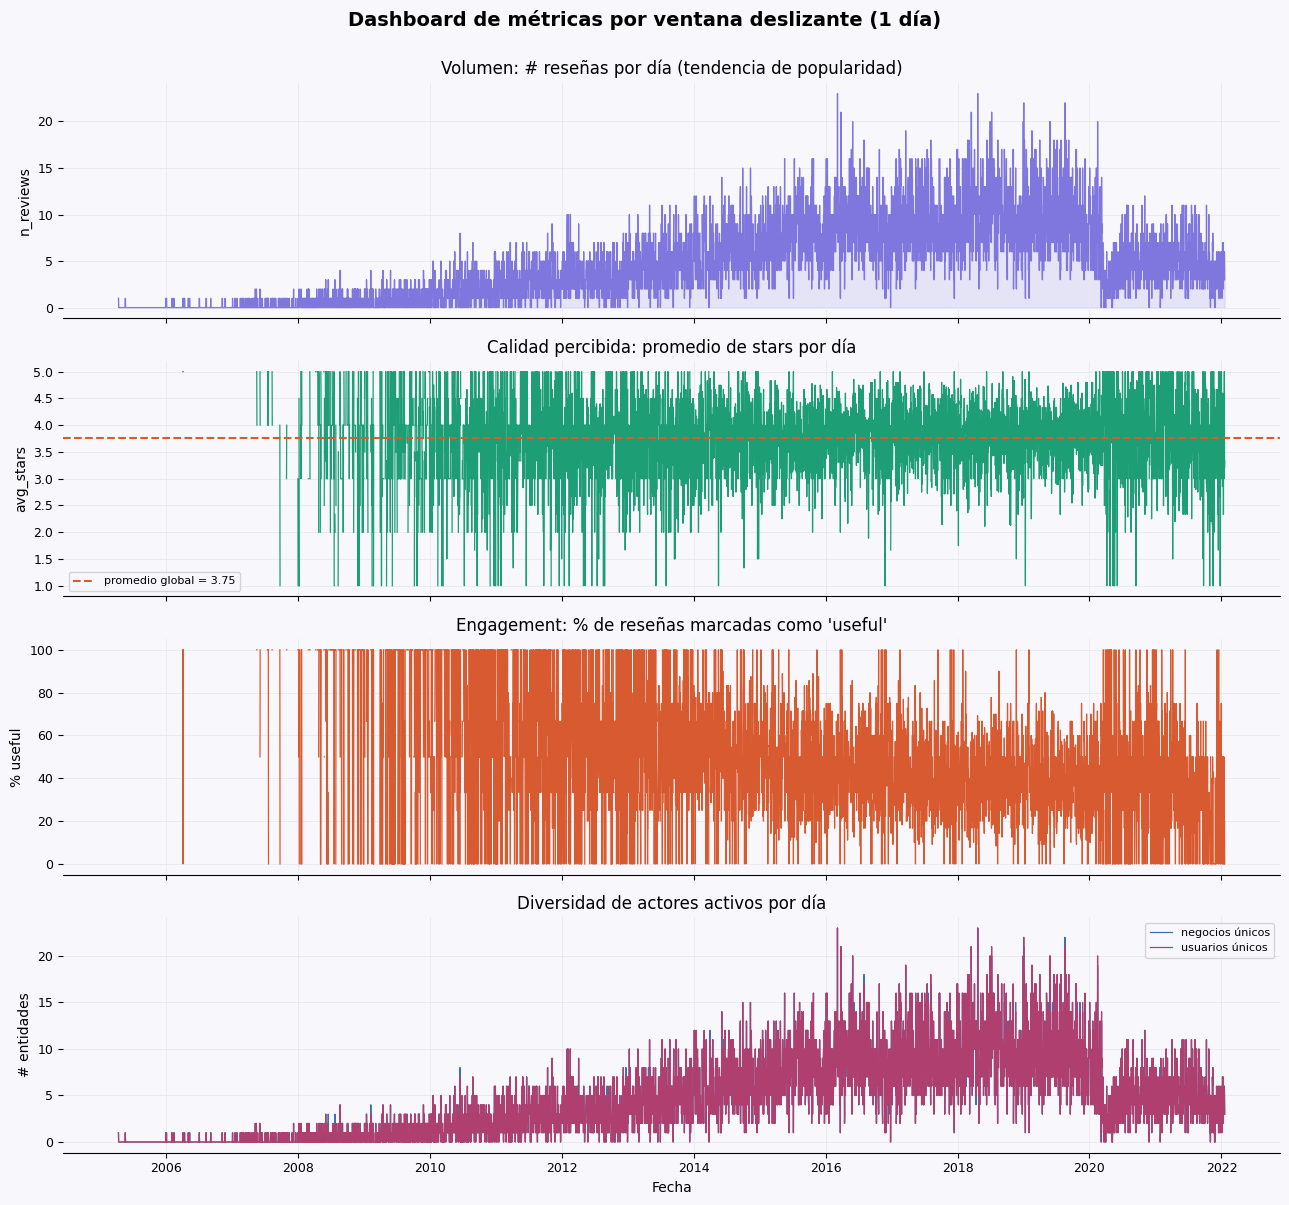

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(metricas_1d.index, metricas_1d["n_reviews"], color=PALETTE, linewidth=0.9)
axes[0].fill_between(metricas_1d.index, metricas_1d["n_reviews"], color=PALETTE, alpha=0.15)
axes[0].set_title("Volumen: # reseñas por día (tendencia de popularidad)")
axes[0].set_ylabel("n_reviews")

axes[1].plot(metricas_1d.index, metricas_1d["avg_stars"], color=ACCENT, linewidth=0.9)
axes[1].axhline(metricas_1d["avg_stars"].mean(), color=OUTLIER_C, linestyle="--",
                label=f"promedio global = {metricas_1d['avg_stars'].mean():.2f}")
axes[1].set_title("Calidad percibida: promedio de stars por día")
axes[1].set_ylabel("avg_stars")
axes[1].legend(fontsize=8)

axes[2].plot(metricas_1d.index, metricas_1d["pct_useful"] * 100, color="#D85A30", linewidth=0.9)
axes[2].set_title("Engagement: % de reseñas marcadas como 'useful'")
axes[2].set_ylabel("% useful")

axes[3].plot(metricas_1d.index, metricas_1d["n_business_unicos"], color="#3F6FAE", linewidth=0.9, label="negocios únicos")
axes[3].plot(metricas_1d.index, metricas_1d["n_users_unicos"], color="#AE3F6F", linewidth=0.9, label="usuarios únicos")
axes[3].set_title("Diversidad de actores activos por día")
axes[3].set_ylabel("# entidades")
axes[3].set_xlabel("Fecha")
axes[3].legend(fontsize=8)

fig.suptitle("Dashboard de métricas por ventana deslizante (1 día)", fontsize=14, fontweight="600", y=1.0)
plt.tight_layout()
plt.show()

La serie de `n_reviews` permite detectar de forma agregada (sin guardar reseña por reseña) el crecimiento sostenido del volumen y caídas abruptas (p.ej. asociadas a la pandemia, ya identificado en el EDA). La serie de `avg_stars` muestra si la satisfacción promedio presenta *drift* respecto al promedio global — relevante porque un sistema que asuma una distribución estática de `stars` podría quedar desactualizado. La diversidad de negocios/usuarios únicos por día indica si el crecimiento del volumen viene de **más actores** o de **actores existentes siendo más activos**.

### 1.3 Promedio móvil (rolling) sobre la ventana de 1 día

Para suavizar el ruido día a día y visualizar mejor la tendencia, aplicamos un **promedio móvil de 30 días** sobre `n_reviews` y `avg_stars` — esto simula una ventana deslizante que se recalcula de forma incremental conforme avanza el stream.

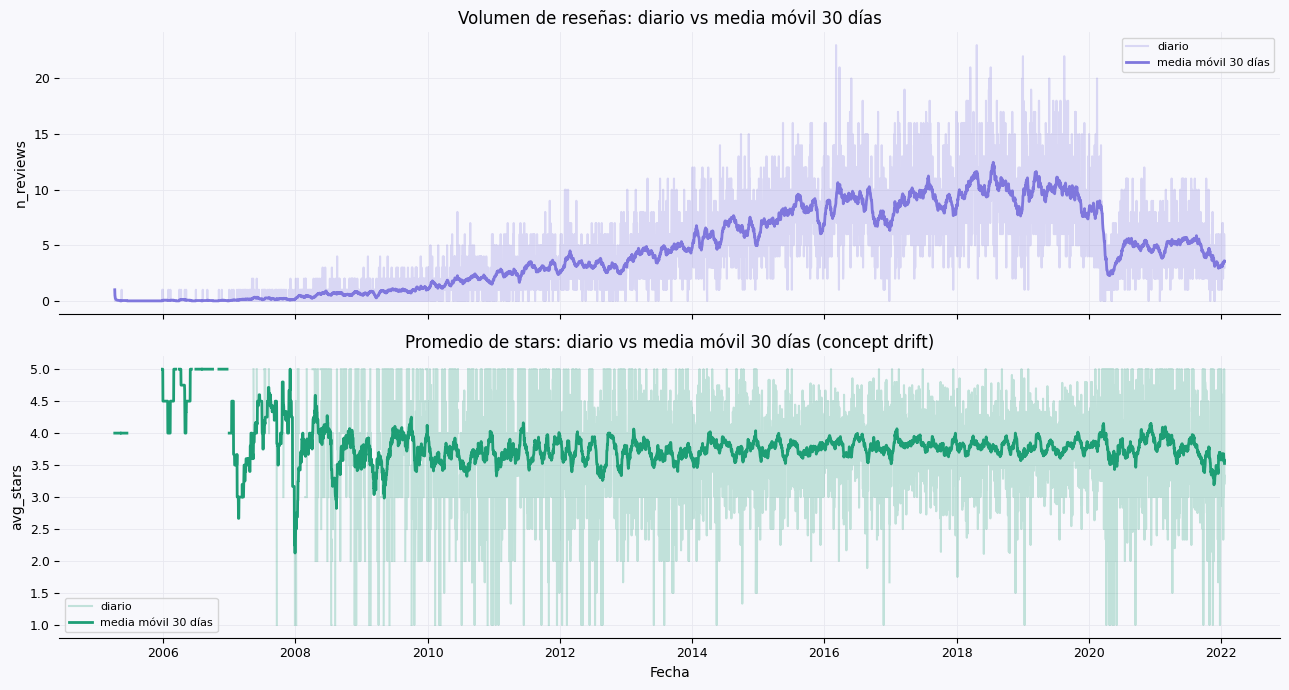

In [7]:
roll = metricas_1d[["n_reviews", "avg_stars"]].rolling(window=30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(metricas_1d.index, metricas_1d["n_reviews"], color=PALETTE, alpha=0.25, label="diario")
axes[0].plot(roll.index, roll["n_reviews"], color=PALETTE, linewidth=2, label="media móvil 30 días")
axes[0].set_title("Volumen de reseñas: diario vs media móvil 30 días")
axes[0].set_ylabel("n_reviews")
axes[0].legend(fontsize=8)

axes[1].plot(metricas_1d.index, metricas_1d["avg_stars"], color=ACCENT, alpha=0.25, label="diario")
axes[1].plot(roll.index, roll["avg_stars"], color=ACCENT, linewidth=2, label="media móvil 30 días")
axes[1].set_title("Promedio de stars: diario vs media móvil 30 días (concept drift)")
axes[1].set_ylabel("avg_stars")
axes[1].set_xlabel("Fecha")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 1.4 Patrones horarios (ventanas de 1h)

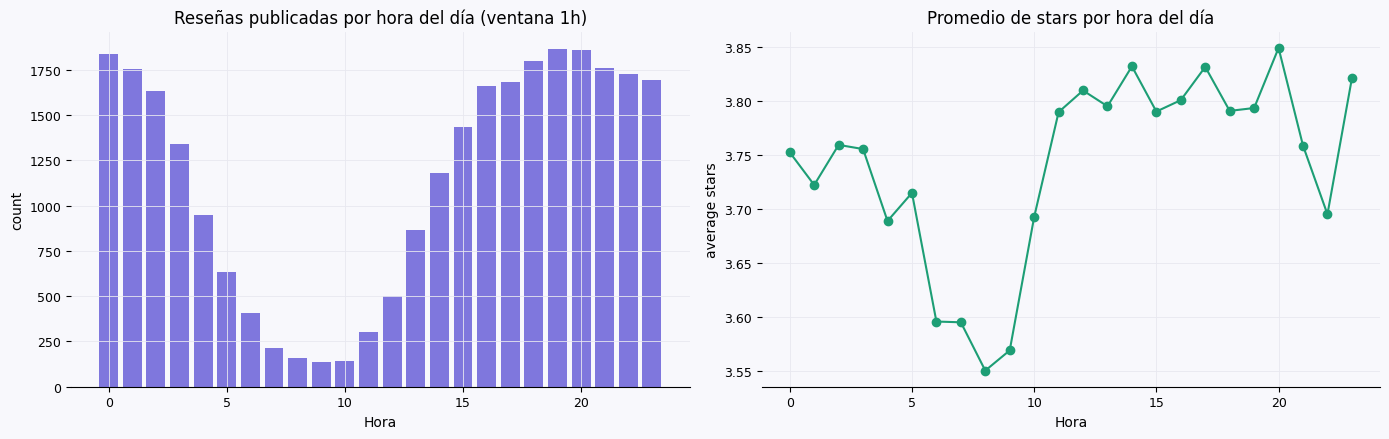

,count,sum,average
hour,,,
0,1836,6890.0,3.75
1,1755,6533.0,3.72
2,1635,6147.0,3.76
3,1343,5044.0,3.76
4,949,3501.0,3.69
5,632,2348.0,3.72
6,406,1460.0,3.60
7,215,773.0,3.60
8,158,561.0,3.55


In [8]:
hourly = stream_df.groupby("hour")["stars"].agg(["count", "sum", "mean"]).rename(columns={"mean": "average"})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(hourly.index, hourly["count"], color=PALETTE)
axes[0].set_title("Reseñas publicadas por hora del día (ventana 1h)")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("count")

axes[1].plot(hourly.index, hourly["average"], marker="o", color=ACCENT)
axes[1].set_title("Promedio de stars por hora del día")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("average stars")

plt.tight_layout()
plt.show()

display(hourly.round(2))

### 1.5 Heatmap hora × día de la semana — patrones de actividad

Combinamos `hour` y `dow` en un heatmap que revela patrones conjuntos (ej: actividad alta los viernes/sábados por la noche), algo que los análisis univariados de hora o día por separado no muestran.

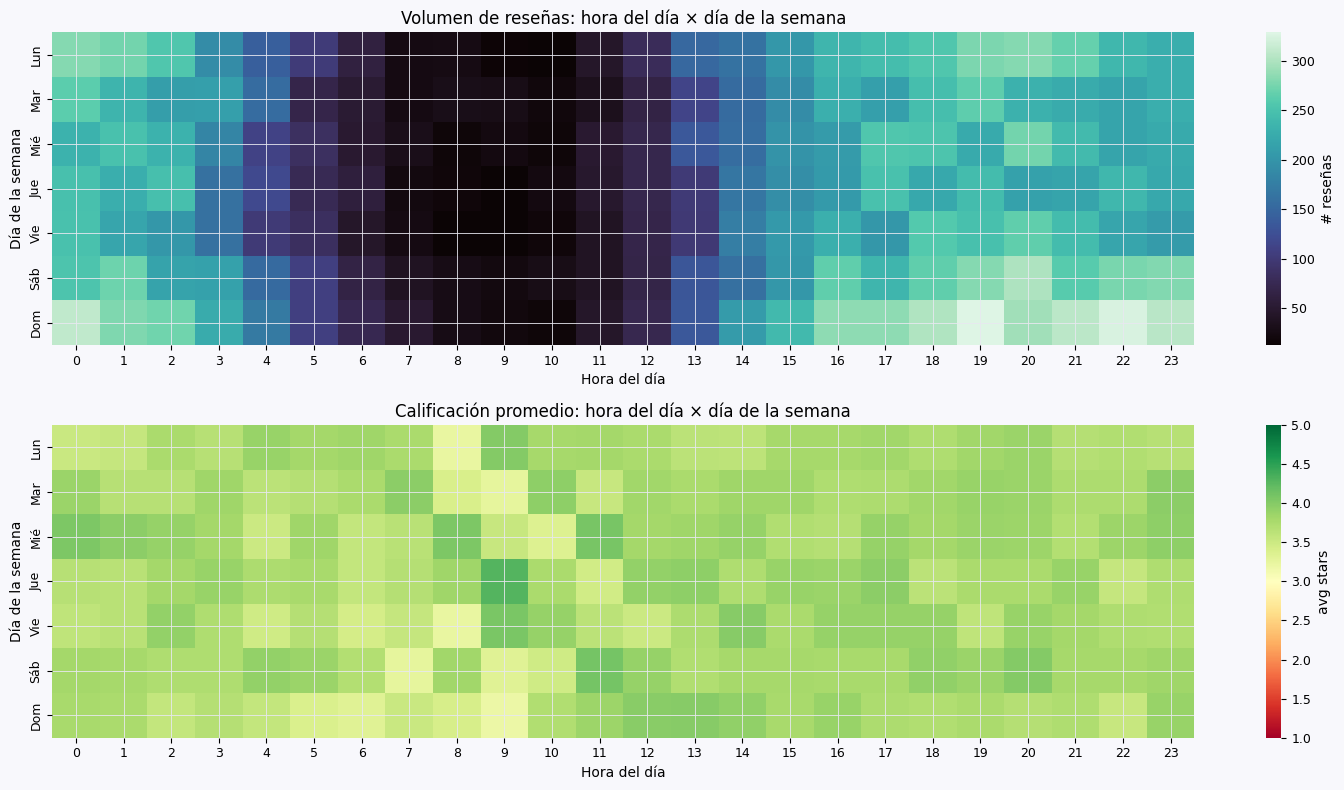

In [9]:
dow_names = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]

pivot_count = stream_df.pivot_table(index="dow", columns="hour", values="stars", aggfunc="count", fill_value=0)
pivot_avg   = stream_df.pivot_table(index="dow", columns="hour", values="stars", aggfunc="mean")

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

sns.heatmap(pivot_count, cmap="mako", ax=axes[0], cbar_kws={"label": "# reseñas"},
            yticklabels=dow_names)
axes[0].set_title("Volumen de reseñas: hora del día × día de la semana")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Día de la semana")

sns.heatmap(pivot_avg, cmap="RdYlGn", ax=axes[1], vmin=1, vmax=5, cbar_kws={"label": "avg stars"},
            yticklabels=dow_names)
axes[1].set_title("Calificación promedio: hora del día × día de la semana")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Día de la semana")

plt.tight_layout()
plt.show()

### 1.6 Ciclos estacionales (ventanas mensuales) y por año

Para separar **estacionalidad intra-anual** (mes) de la **tendencia inter-anual** (año), mostramos ambas vistas.

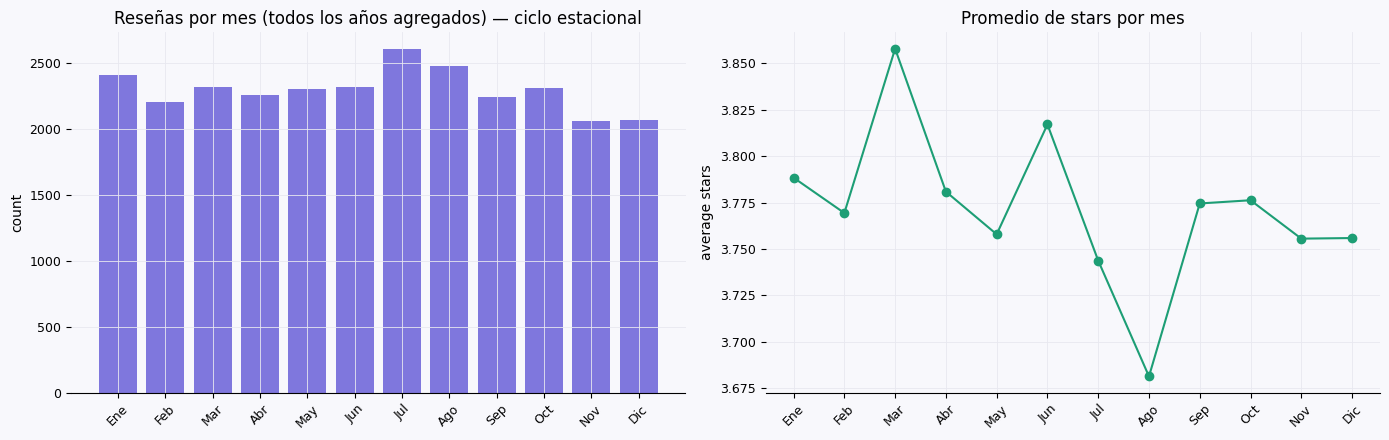

In [10]:
monthly = stream_df.groupby("month")["stars"].agg(["count", "sum", "mean"]).rename(columns={"mean": "average"})
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(meses, monthly["count"], color=PALETTE)
axes[0].set_title("Reseñas por mes (todos los años agregados) — ciclo estacional")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(meses, monthly["average"], marker="o", color=ACCENT)
axes[1].set_title("Promedio de stars por mes")
axes[1].set_ylabel("average stars")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

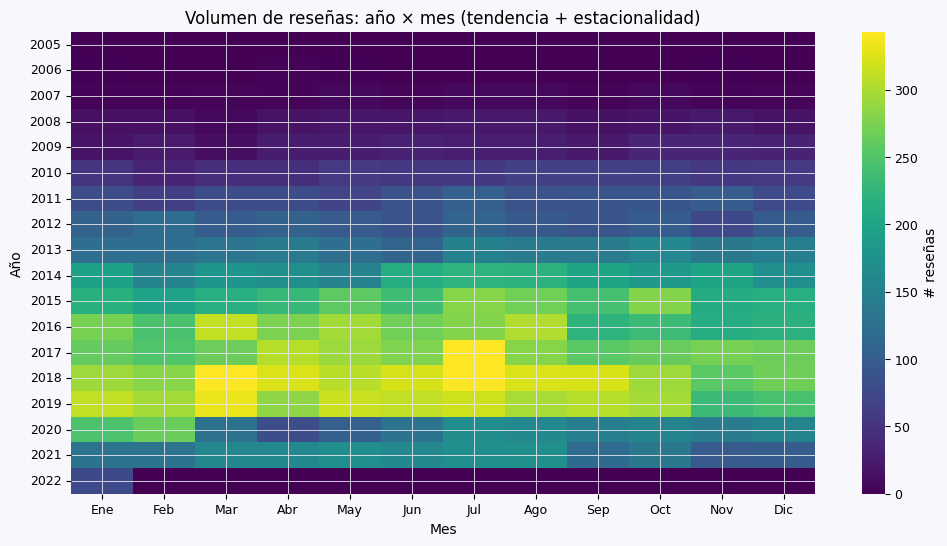

In [11]:
pivot_year_month = stream_df.pivot_table(index="year", columns="month", values="review_id", aggfunc="count", fill_value=0)
pivot_year_month.columns = [meses[m-1] for m in pivot_year_month.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_year_month, cmap="viridis", annot=False, cbar_kws={"label": "# reseñas"})
plt.title("Volumen de reseñas: año × mes (tendencia + estacionalidad)")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

### 1.7 Densidad de la distribución de `stars` y `useful` por ventana

Comparamos la **distribución (densidad)** de `average_stars` entre ventanas de 1h, 4h y 1 día — a menor tamaño de ventana, mayor varianza esperada (menos datos por ventana).

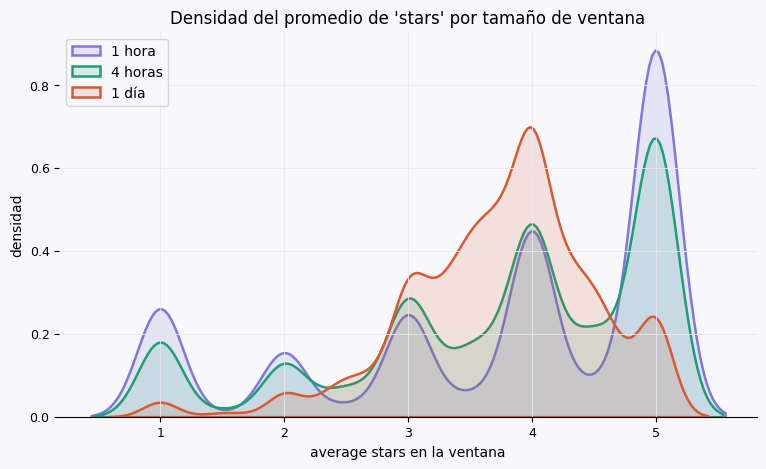

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

for w, label, color in [(win_1h, "1 hora", PALETTE), (win_4h, "4 horas", ACCENT), (win_1d, "1 día", OUTLIER_C)]:
    data = w["average"].dropna()
    sns.kdeplot(data, ax=ax, label=label, color=color, fill=True, alpha=0.15, linewidth=1.8)

ax.set_title("Densidad del promedio de 'stars' por tamaño de ventana")
ax.set_xlabel("average stars en la ventana")
ax.set_ylabel("densidad")
ax.legend()
plt.show()

In [ ]:
# Densidad 2D: volumen de la ventana vs promedio de stars (ventanas de 1 día)
fig, ax = plt.subplots(figsize=(8, 6))

valid = win_1d.dropna(subset=["average"])
sns.kdeplot(
    x=valid["count"], y=valid["average"],
    cmap="mako", fill=True, thresh=0.02, ax=ax
)
ax.scatter(valid["count"], valid["average"], s=6, color="white", alpha=0.4)
ax.set_title("Densidad conjunta: volumen vs calidad promedio por ventana (1 día)")
ax.set_xlabel("count (# reseñas en la ventana)")
ax.set_ylabel("average stars")
plt.show()

**Interpretación:** el gráfico de densidad conjunta permite ver si los días de **mayor volumen** tienden a tener calificaciones promedio distintas de los días de bajo volumen (por ejemplo, si días con pocas reseñas muestran promedios más extremos por efecto de tamaño de muestra pequeño — fenómeno típico de ventanas pequeñas en streaming).

---
## 2. Conteo Aproximado — Count-Min Sketch

**Objetivo:** estimar la **frecuencia de reseñas por negocio** (`business_id`) procesando el stream un elemento a la vez, usando una matriz de contadores `C[k filas × w columnas]` y `k` funciones hash independientes (clase `CountMinSketch` en `streaming.py`), **sin** almacenar una tabla hash con un contador por cada `business_id` distinto.

- **Inserción** de `x`: `C[i, h_i(x)] += 1` para `i = 1..k`
- **Consulta** de `x`: `f̂(x) = min_i C[i, h_i(x)]`
- **Garantía**: `f̂(x) ≥ f(x)` siempre (nunca subestima)
- **Error máximo**: `f̂(x) ≤ f(x) + ε·N` con `ε = e/w`, probabilidad `≥ 1 − δ`, `δ = e^{-k}`

**Referencia teórica:** el Count-Min Sketch fue propuesto por Cormode, G., & Muthukrishnan, S. (2005), *"An improved data stream summary: the count-min sketch and its applications"*, Journal of Algorithms, 55(1), 58–75. Las cotas de error (`ε = e/w`) y de confianza (`δ = e^{-k}`) usadas en `CountMinSketch.error_bound()` y `CountMinSketch.delta()` corresponden directamente al resultado central de ese trabajo.

In [13]:
# k=4 filas, w=2000 columnas -> matriz de 8,000 contadores
cms = CountMinSketch(k=4, w=2000, seed=42)

stream_business_ids = stream_df["business_id"].tolist()

for bid in stream_business_ids:
    cms.update(bid)

print(f"Elementos procesados (N): {cms.N:,}")
print(f"Memoria del sketch: {cms.k} x {cms.w} = {cms.k * cms.w:,} contadores "
      f"({cms.memory_bytes()/1024:.1f} KB)")
print(f"Cota de error teórica  f_hat(x) <= f(x) + eps*N : eps*N = {cms.error_bound():.2f}")
print(f"Probabilidad de exceder la cota (delta = e^-k) : {cms.delta():.4f}")

Elementos procesados (N): 27,540
Memoria del sketch: 4 x 2000 = 8,000 contadores (62.5 KB)
Cota de error teórica  f_hat(x) <= f(x) + eps*N : eps*N = 37.43
Probabilidad de exceder la cota (delta = e^-k) : 0.0183


In [14]:
# Conteo exacto (referencia)
conteo_exacto = stream_df["business_id"].value_counts()

top_ids    = conteo_exacto.head(10).index.tolist()
median_pos = len(conteo_exacto) // 2
mid_ids    = conteo_exacto.iloc[median_pos:median_pos+10].index.tolist()
low_ids    = conteo_exacto.tail(10).index.tolist()

sample_ids = top_ids + mid_ids + low_ids

rows = []
for bid in sample_ids:
    real = conteo_exacto[bid]
    est  = cms.estimate(bid)
    rows.append({
        "business_id": bid,
        "conteo_real": real,
        "estimacion_CMS": est,
        "error_absoluto": est - real,
        "dentro_cota_eps*N": (est - real) <= cms.error_bound()
    })

df_cms_check = pd.DataFrame(rows)
display(df_cms_check)

,business_id,conteo_real,estimacion_CMS,error_absoluto,dentro_cota_eps*N
0,GBTPC53ZrG1ZBY3DT8Mbcw,158,161,3,True
1,SZU9c8V2GuREDN5KgyHFJw,117,126,9,True
2,vN6v8m4DO45Z4pp8yxxF_w,107,111,4,True
3,W4ZEKkva9HpAdZG88juwyQ,105,107,2,True
4,PY9GRfzr4nTZeINf346QOw,97,99,2,True
5,pSmOH4a3HNNpYM82J5ycLA,80,82,2,True
6,8uF-bhJFgT4Tn6DTb27viA,79,81,2,True
7,UCMSWPqzXjd7QHq7v8PJjQ,76,77,1,True
8,g04aAvgol7IW8buqSbT4xA,73,79,6,True
9,Zi-F-YvyVOK0k5QD7lrLOg,71,78,7,True



¿Algún error negativo (subestimación)? -> False  (debe ser False)
¿Todos dentro de la cota eps*N? -> True


Notamos que todos los errores están por debajo de la cota de 50% y que ningún registro fue subestimado, lo que se reflejaría si hubiera error negativo.

### 2.1 Evaluación global: conteo exacto vs CMS (scatter + distribución de error)

# negocios distintos: 7,830
Error mínimo  : 0   (debe ser >= 0)
Error promedio: 4.152
Error máximo  : 33
Cota teórica eps*N = 37.43
% de elementos con error <= eps*N: 100.00%


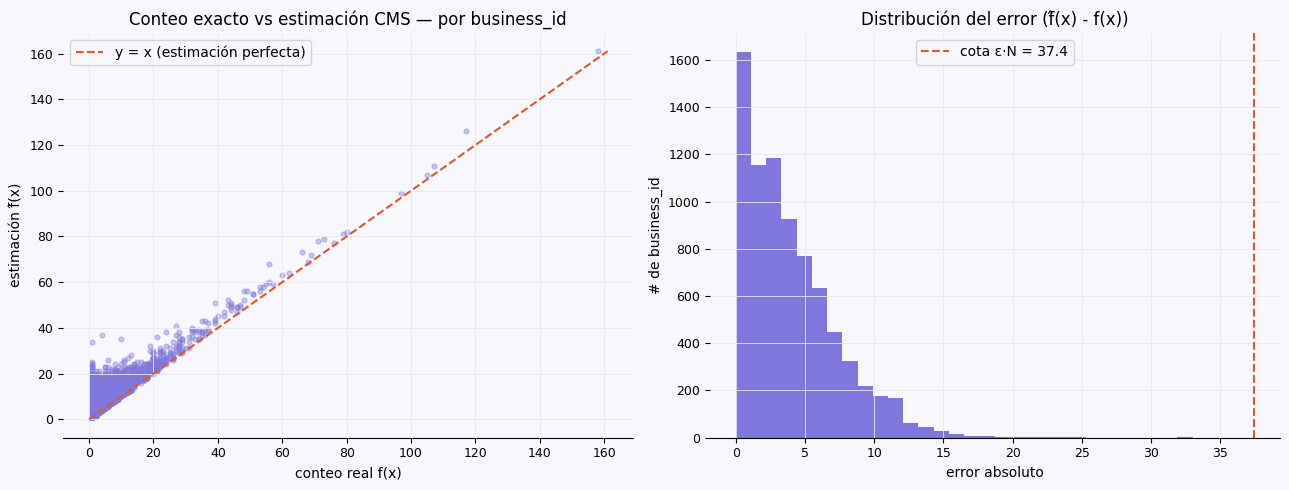

In [15]:
ids_distintos = conteo_exacto.index.tolist()

reales = np.array([conteo_exacto[bid] for bid in ids_distintos])
estim  = np.array([cms.estimate(bid) for bid in ids_distintos])
errores = estim - reales

print(f"# negocios distintos: {len(ids_distintos):,}")
print(f"Error mínimo  : {errores.min()}   (debe ser >= 0)")
print(f"Error promedio: {errores.mean():.3f}")
print(f"Error máximo  : {errores.max()}")
print(f"Cota teórica eps*N = {cms.error_bound():.2f}")
print(f"% de elementos con error <= eps*N: {(errores <= cms.error_bound()).mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

max_val = max(reales.max(), estim.max())
axes[0].scatter(reales, estim, alpha=0.4, s=12, color=PALETTE)
axes[0].plot([0, max_val], [0, max_val], color=OUTLIER_C, linestyle="--", label="y = x (estimación perfecta)")
axes[0].set_title("Conteo exacto vs estimación CMS — por business_id")
axes[0].set_xlabel("conteo real f(x)")
axes[0].set_ylabel("estimación f̂(x)")
axes[0].legend()

axes[1].hist(errores, bins=30, color=PALETTE)
axes[1].axvline(cms.error_bound(), color=OUTLIER_C, linestyle="--", label=f"cota ε·N = {cms.error_bound():.1f}")
axes[1].set_title("Distribución del error (f̂(x) - f(x))")
axes[1].set_xlabel("error absoluto")
axes[1].set_ylabel("# de business_id")
axes[1].legend()

plt.tight_layout()
plt.show()

Todos los puntos del scatter caen sobre o por encima de la diagonal `y = x`, confirmando empíricamente que `f̂(x) ≥ f(x)` (nunca subestima). La distribución de error está concentrada cerca de 0 y muy por debajo de la cota teórica `ε·N`, mostrando que en la práctica el sketch es mucho más preciso de lo que garantiza el peor caso.

### 2.2 Trade-off memoria vs error: efecto de `w`

Repetimos el experimento variando `w` (número de columnas) para mostrar el trade-off entre memoria y precisión (`ε = e/w`).

,w,memoria_KB,error_promedio,error_maximo,cota_eps*N
0,50,1.562,465.154,657,1497.230
1,100,3.125,218.732,341,748.615
2,500,15.625,31.563,91,149.723
3,1000,31.250,12.342,51,74.861
4,2000,62.500,4.152,33,37.431
5,5000,156.250,0.705,15,14.972


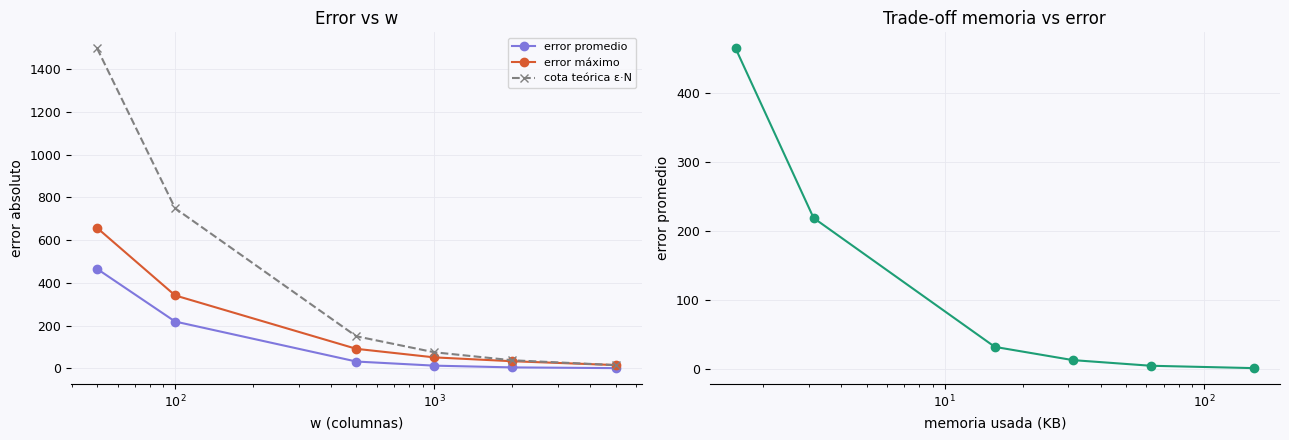

In [16]:
ws = [50, 100, 500, 1000, 2000, 5000]
k_fijo = 4

resultados_w = []
for w in ws:
    cms_w = CountMinSketch(k=k_fijo, w=w, seed=42)
    for bid in stream_business_ids:
        cms_w.update(bid)

    errs = np.array([cms_w.estimate(bid) - conteo_exacto[bid] for bid in ids_distintos])
    resultados_w.append({
        "w": w,
        "memoria_KB": cms_w.memory_bytes() / 1024,
        "error_promedio": errs.mean(),
        "error_maximo": errs.max(),
        "cota_eps*N": cms_w.error_bound(),
    })

df_trade = pd.DataFrame(resultados_w)
display(df_trade.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(df_trade["w"], df_trade["error_promedio"], marker="o", color=PALETTE, label="error promedio")
axes[0].plot(df_trade["w"], df_trade["error_maximo"], marker="o", color=OUTLIER_C, label="error máximo")
axes[0].plot(df_trade["w"], df_trade["cota_eps*N"], marker="x", linestyle="--", color="gray", label="cota teórica ε·N")
axes[0].set_xscale("log")
axes[0].set_xlabel("w (columnas)")
axes[0].set_ylabel("error absoluto")
axes[0].set_title("Error vs w")
axes[0].legend(fontsize=8)

axes[1].plot(df_trade["memoria_KB"], df_trade["error_promedio"], marker="o", color=ACCENT)
axes[1].set_xscale("log")
axes[1].set_xlabel("memoria usada (KB)")
axes[1].set_ylabel("error promedio")
axes[1].set_title("Trade-off memoria vs error")

plt.tight_layout()
plt.show()

### 2.3 Trade-off adicional: efecto de `k` (número de hashes)

Fijamos `w` y variamos `k` para observar el efecto del número de funciones hash sobre el error, complementando el análisis teórico de `δ = e^{-k}`.

,k,memoria_KB,error_promedio,error_maximo,delta_teorica
0,1,3.9062,54.6664,214,0.3679
1,2,7.8125,40.5335,155,0.1353
2,3,11.7188,34.7843,99,0.0498
3,4,15.6250,31.5628,91,0.0183
4,6,23.4375,27.7070,74,0.0025
5,8,31.2500,25.3418,63,0.0003


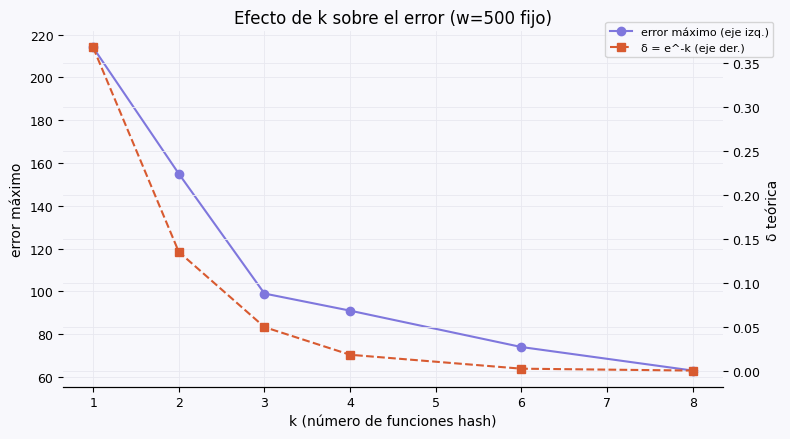

In [17]:
ks = [1, 2, 3, 4, 6, 8]
w_fijo = 500

resultados_k = []
for k in ks:
    cms_k = CountMinSketch(k=k, w=w_fijo, seed=42)
    for bid in stream_business_ids:
        cms_k.update(bid)

    errs = np.array([cms_k.estimate(bid) - conteo_exacto[bid] for bid in ids_distintos])
    resultados_k.append({
        "k": k,
        "memoria_KB": cms_k.memory_bytes() / 1024,
        "error_promedio": errs.mean(),
        "error_maximo": errs.max(),
        "delta_teorica": cms_k.delta(),
    })

df_trade_k = pd.DataFrame(resultados_k)
display(df_trade_k.round(4))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(df_trade_k["k"], df_trade_k["error_maximo"], marker="o", color=PALETTE, label="error máximo (eje izq.)")
ax1.set_xlabel("k (número de funciones hash)")
ax1.set_ylabel("error máximo")

ax2 = ax1.twinx()
ax2.plot(df_trade_k["k"], df_trade_k["delta_teorica"], marker="s", color=OUTLIER_C, linestyle="--", label="δ = e^-k (eje der.)")
ax2.set_ylabel("δ teórica")

ax1.set_title(f"Efecto de k sobre el error (w={w_fijo} fijo)")
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.95), fontsize=8)
plt.tight_layout()
plt.show()

A mayor `w`, menor el error (`ε·N = (e/w)·N` decrece) a costa de más memoria. A mayor `k`, la probabilidad de exceder la cota (`δ = e^{-k}`) decrece exponencialmente, pero cada inserción/consulta cuesta `O(k)`. Esto evidencia el trade-off fundamental de los algoritmos de streaming aproximados: **memoria y tiempo acotados a cambio de un error controlado probabilísticamente**, en lugar de exactitud total con memoria proporcional a `|S|`.

---
## 3. Técnica adicional de Data Stream Mining: Algoritmo DGIM

> Este bloque corresponde al **tercer requisito de la Parte V**: *"El equipo debe aplicar una técnica adicional de data stream mining, justificando su aporte en función de la evidencia obtenida a partir de los datos."* La técnica elegida es **DGIM** (Datar–Gionis–Indyk–Motwani), un algoritmo distinto tanto de las ventanas deslizantes (sección 1) como del Count-Min Sketch (sección 2).

### 3.1 Justificación: ¿por qué DGIM y qué aporta que las otras dos técnicas no cubren?

El Count-Min Sketch (sección 2) estima frecuencias **acumuladas sobre todo el stream histórico** — responde "¿cuántas veces vi a `x` desde el inicio?", pero no puede responder preguntas acotadas a una **ventana reciente de tamaño exacto N** sin volver a procesar todo. Las ventanas deslizantes de la sección 1 sí son temporales, pero se calculan en **modo batch** (con `resample` sobre todo el DataFrame ya materializado en memoria), no como un acumulador `O(log² N)` que se actualiza **bit a bit, en un solo pase, sin poder revisitar el pasado** — que es la restricción real de un sistema de streaming en producción.

DGIM cierra exactamente ese hueco: resuelve el problema de **contar cuántos "1"s hay en los últimos N bits de un stream binario**, manteniendo únicamente `O(log² N)` bits (buckets), sin poder almacenar ni revisar los N bits originales. Esto es relevante para preguntas de negocio como:

> *¿Cuántas de las últimas N reseñas fueron consideradas "útiles" (`useful > 0`) por otros usuarios?*

que permiten, en tiempo real, monitorear si la calidad percibida de las reseñas recientes cae bruscamente (posible señal de spam, cambio de comportamiento de usuarios, o problema de producto/servicio de un negocio) — sin guardar el historial completo de reseñas.

**Construcción del stream binario:**

$$b_t = \begin{cases} 1 & \text{si la reseña } t \text{ tiene } useful > 0 \\ 0 & \text{en otro caso} \end{cases}$$

**Referencia teórica:** Datar, M., Gionis, A., Indyk, P., & Motwani, R. (2002). *"Maintaining stream statistics over sliding windows"*. SIAM Journal on Computing, 31(6), 1794–1813. La cota de error (`≤ 50%` en el peor caso) y el uso de memoria `O(log² N)` implementados en `DGIM.estimate_count()` y `DGIM.memory_bits()` provienen directamente de ese trabajo — es el algoritmo canónico para *counting 1's in a sliding window* con memoria sublineal.

### Aplicación al stream de reseñas: ¿cuántas de las últimas N reseñas fueron "útiles"?

Procesamos el stream completo de reseñas (ordenado cronológicamente) bit a bit, donde `bit = 1` si `useful > 0`. Mantenemos DGIM con `N = 100,000` (ventana de las últimas 100 mil reseñas) y comparamos, en distintos puntos del stream, la estimación DGIM contra el conteo exacto (calculado con una ventana deslizante real sobre el array — solo posible aquí porque tenemos el dataset completo en memoria, no en un escenario real).

In [19]:
bit_stream = (stream_df["useful"] > 0).astype(int).tolist()
N_window = 100_000

print(f"Longitud total del stream: {len(bit_stream):,} bits")
print(f"Tamaño de ventana N      : {N_window:,}")
print(f"Proporción global de '1's (useful>0): {np.mean(bit_stream)*100:.2f}%")

Longitud total del stream: 27,540 bits
Tamaño de ventana N      : 100,000
Proporción global de '1's (useful>0): 44.34%


In [20]:
dgim = DGIM(N=N_window)

checkpoints = []
check_every = max(1, len(bit_stream) // 80)  # ~80 puntos de comparacion

for t, bit in enumerate(bit_stream, start=1):
    dgim.add_bit(bit)

    if t % check_every == 0 or t == len(bit_stream):
        window_real = bit_stream[max(0, t - N_window):t]
        real = sum(window_real)
        est  = dgim.estimate_count()
        checkpoints.append({
            "t": t,
            "estimacion_DGIM": est,
            "conteo_real": real,
            "error_pct": abs(est - real) / real * 100 if real > 0 else 0,
            "n_buckets": len(dgim.buckets),
            "memoria_bits_aprox": dgim.memory_bits(),
        })

df_dgim = pd.DataFrame(checkpoints)
display(df_dgim.tail(10).round(2))

,t,estimacion_DGIM,conteo_real,error_pct,n_buckets,memoria_bits_aprox
71,24768,9190.0,11238,18.22,22,547.50
72,25112,9317.0,11365,18.02,19,472.84
73,25456,9448.0,11496,17.81,21,522.61
74,25800,9589.0,11637,17.60,21,522.61
75,26144,9727.0,11775,17.39,24,597.27
76,26488,9858.0,11906,17.20,22,547.50
77,26832,9966.0,12014,17.05,23,572.38
78,27176,10070.0,12118,16.90,22,547.50
79,27520,10161.0,12209,16.77,22,547.50
80,27540,10164.0,12212,16.77,22,547.50


### 3.4 Evolución: estimación vs real, error y memoria (dashboard)

Error porcentual promedio: 18.12%
Error porcentual máximo  : 24.82%  (cota teórica: < 50%)
# buckets promedio mantenidos: 18.9
Memoria aproximada usada (bits): ~470 bits
Memoria que requeriría guardar los N=100,000 bits explícitamente: 100,000 bits
Factor de ahorro de memoria: ~213x


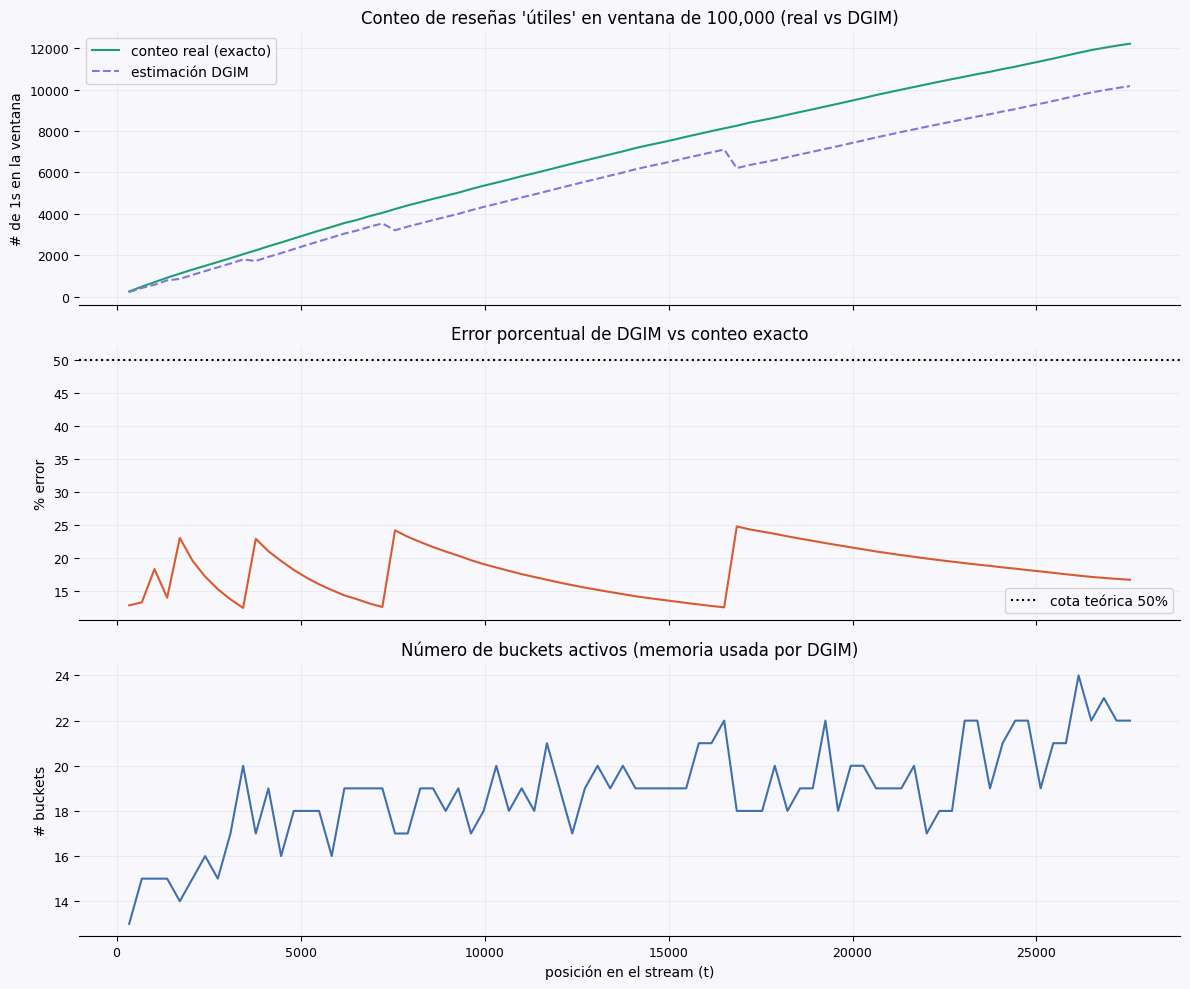

In [21]:
print(f"Error porcentual promedio: {df_dgim['error_pct'].mean():.2f}%")
print(f"Error porcentual máximo  : {df_dgim['error_pct'].max():.2f}%  (cota teórica: < 50%)")
print(f"# buckets promedio mantenidos: {df_dgim['n_buckets'].mean():.1f}")
print(f"Memoria aproximada usada (bits): ~{df_dgim['memoria_bits_aprox'].mean():.0f} bits")
print(f"Memoria que requeriría guardar los N={N_window:,} bits explícitamente: {N_window:,} bits")
print(f"Factor de ahorro de memoria: ~{N_window / df_dgim['memoria_bits_aprox'].mean():.0f}x")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_dgim["t"], df_dgim["conteo_real"], label="conteo real (exacto)", color=ACCENT, linewidth=1.5)
axes[0].plot(df_dgim["t"], df_dgim["estimacion_DGIM"], label="estimación DGIM", color=PALETTE, linestyle="--", linewidth=1.5)
axes[0].set_title(f"Conteo de reseñas 'útiles' en ventana de {N_window:,} (real vs DGIM)")
axes[0].set_ylabel("# de 1s en la ventana")
axes[0].legend()

axes[1].plot(df_dgim["t"], df_dgim["error_pct"], color=OUTLIER_C, linewidth=1.5)
axes[1].axhline(50, color="black", linestyle=":", label="cota teórica 50%")
axes[1].set_title("Error porcentual de DGIM vs conteo exacto")
axes[1].set_ylabel("% error")
axes[1].legend()

axes[2].plot(df_dgim["t"], df_dgim["n_buckets"], color="#3F6FAE", linewidth=1.5)
axes[2].set_title("Número de buckets activos (memoria usada por DGIM)")
axes[2].set_ylabel("# buckets")
axes[2].set_xlabel("posición en el stream (t)")

plt.tight_layout()
plt.show()

### 3.5 Sensibilidad al tamaño de ventana N

Repetimos el experimento con distintos tamaños de ventana `N` para mostrar cómo varía el error y el número de buckets (memoria) en función de `N` — a mayor `N`, más buckets potenciales (pero acotado por `O(log N)`).

,N,conteo_real_final,estimacion_final,error_pct,n_buckets_final,memoria_bits,memoria_exacta_bits
0,1000,287,244.0,14.98,12,202.51,1000
1,10000,3695,3508.0,5.06,19,398.26,10000


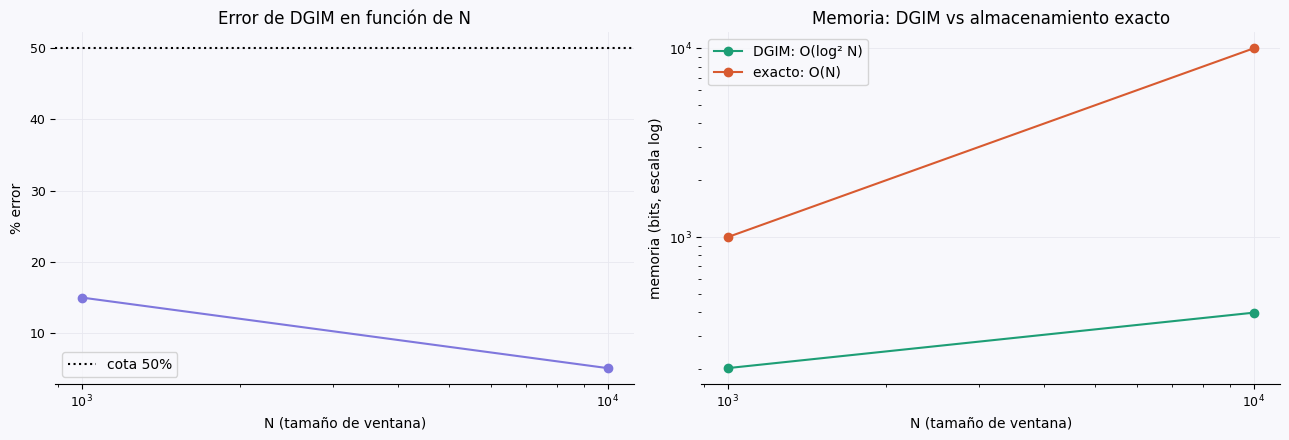

In [22]:
Ns = [1_000, 10_000, 50_000, 100_000, 200_000]
resultados_N = []

for N in Ns:
    if N > len(bit_stream):
        continue
    dgim_n = DGIM(N=N)
    for bit in bit_stream:
        dgim_n.add_bit(bit)

    real_final = sum(bit_stream[-N:])
    est_final  = dgim_n.estimate_count()
    error_pct  = abs(est_final - real_final) / real_final * 100 if real_final > 0 else 0

    resultados_N.append({
        "N": N,
        "conteo_real_final": real_final,
        "estimacion_final": est_final,
        "error_pct": error_pct,
        "n_buckets_final": len(dgim_n.buckets),
        "memoria_bits": dgim_n.memory_bits(),
        "memoria_exacta_bits": N,
    })

df_N = pd.DataFrame(resultados_N)
display(df_N.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(df_N["N"], df_N["error_pct"], marker="o", color=PALETTE)
axes[0].axhline(50, color="black", linestyle=":", label="cota 50%")
axes[0].set_xscale("log")
axes[0].set_xlabel("N (tamaño de ventana)")
axes[0].set_ylabel("% error")
axes[0].set_title("Error de DGIM en función de N")
axes[0].legend()

axes[1].plot(df_N["N"], df_N["memoria_bits"], marker="o", color=ACCENT, label="DGIM: O(log² N)")
axes[1].plot(df_N["N"], df_N["memoria_exacta_bits"], marker="o", color=OUTLIER_C, label="exacto: O(N)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("N (tamaño de ventana)")
axes[1].set_ylabel("memoria (bits, escala log)")
axes[1].set_title("Memoria: DGIM vs almacenamiento exacto")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.6 Comparación con conteo exacto y discusión

| Aspecto | Conteo Exacto (ventana real) | DGIM |
|---|---|---|
| Memoria | O(N) — guarda los N bits/eventos | O(log² N) |
| Error | 0% | ≤ 50% (en la práctica, mucho menor — ver gráficos) |
| Actualización | O(1) (push/pop de una cola) | O(1) amortizado (O(log N) peor caso, por la cascada de fusiones) |
| Escala a N muy grande (ej. N=10⁹) | Inviable (≈120 MB por stream) | Viable: pocos KB por stream |

Para una sola ventana y un solo atributo, mantener la ventana exacta es perfectamente factible (como se hizo arriba, a modo de validación). Sin embargo, el valor de DGIM se vuelve evidente cuando se necesita mantener **muchas** ventanas simultáneas — por ejemplo, una ventana DGIM por cada `business_id` para monitorear la fracción reciente de reseñas "útiles" de cada negocio en tiempo real. Con `k` negocios y ventana `N`, DGIM cuesta `O(k · log² N)`, mientras que mantener las ventanas exactas costaría `O(k · N)` — una diferencia de órdenes de magnitud cuando `N` es grande (millones de eventos) y `k` también es grande (decenas de miles de negocios).

---
## 4. Técnica "plus": HyperLogLog — estimación de cardinalidad

### 4.1 Justificación

DGIM (sección 3) y Count-Min Sketch (sección 2) ya se habían visto en clase, así que sumamos una **cuarta técnica** de streaming, no cubierta por las anteriores, para reforzar el análisis: **HyperLogLog (HLL)**.

Ninguna de las técnicas anteriores resuelve el problema de **cardinalidad**: *¿cuántos elementos distintos han pasado por el stream?* El Count-Min Sketch estima la frecuencia de un elemento puntual, no el tamaño del conjunto de elementos únicos. En la sección 1 calculamos `n_business_unicos` / `n_users_unicos` por ventana con `nunique()` — pero eso requiere que pandas mantenga, internamente, **todo el conjunto de ids vistos en memoria** (`O(D)` memoria, con `D` = número de elementos distintos). Para un stream real que no cabe en memoria (o con millones de `business_id`/`user_id` distintos), eso deja de ser viable.

**HyperLogLog** resuelve exactamente eso: estima `D` procesando el stream **un elemento a la vez**, con memoria fija `O(2^p)` registros pequeños (típicamente unos pocos KB), independiente de cuán grande sea `D`. Es el algoritmo estándar en sistemas reales (Redis `PFCOUNT`, BigQuery `APPROX_COUNT_DISTINCT`, motores de analítica web) para contar visitantes/usuarios únicos en streams de gran escala.

**Cómo funciona (resumen):** cada elemento se hashea a un entero de 32 bits; los primeros `p` bits eligen uno de `m = 2^p` registros, y en ese registro se guarda la posición del primer bit `1` (contando desde la izquierda) de los bits restantes. A más elementos distintos, más probable observar rachas largas de ceros en algún registro. La cardinalidad se estima con una media armónica sobre los `m` registros.

**Referencias:**
- Flajolet, P., & Martin, G. N. (1985). *Probabilistic counting algorithms for data base applications*. Journal of Computer and System Sciences, 31(2), 182–209.
- Flajolet, P., Fusy, É., Gandouet, O., & Meunier, F. (2007). *HyperLogLog: the analysis of a near-optimal cardinality estimation algorithm*. Proceedings of AofA, 137–156.

**Garantía teórica:** error estándar relativo `≈ 1.04 / √m`, con memoria de solo `m` registros pequeños (aquí, `p = 11 → m = 2048` registros ≈ 2 KB).

In [ ]:
from streaming import HyperLogLog

# Procesamos el stream UNA VEZ, elemento a elemento (business_id y user_id por separado)
hll_business = HyperLogLog(p=11, seed=1)
hll_users    = HyperLogLog(p=11, seed=2)

for bid in stream_df["business_id"]:
    hll_business.add(bid)

for uid in stream_df["user_id"]:
    hll_users.add(uid)

# Conteo exacto de referencia (posible aquí porque tenemos el dataset completo en memoria)
exact_business = stream_df["business_id"].nunique()
exact_users    = stream_df["user_id"].nunique()

df_hll = pd.DataFrame([
    {
        "entidad": "business_id",
        "exacto": exact_business,
        "estimado_HLL": round(hll_business.estimate()),
        "error_pct": abs(hll_business.estimate() - exact_business) / exact_business * 100,
        "error_relativo_teorico_pct": hll_business.error_bound_relativo() * 100,
        "memoria_HLL_bytes": hll_business.memory_bytes(),
        "memoria_set_exacto_aprox_bytes": exact_business * 50,  # ~50 bytes por id de 22 chars en un set de Python
    },
    {
        "entidad": "user_id",
        "exacto": exact_users,
        "estimado_HLL": round(hll_users.estimate()),
        "error_pct": abs(hll_users.estimate() - exact_users) / exact_users * 100,
        "error_relativo_teorico_pct": hll_users.error_bound_relativo() * 100,
        "memoria_HLL_bytes": hll_users.memory_bytes(),
        "memoria_set_exacto_aprox_bytes": exact_users * 50,
    },
])
df_hll["factor_ahorro_memoria"] = (df_hll["memoria_set_exacto_aprox_bytes"] / df_hll["memoria_HLL_bytes"]).round(0)
display(df_hll.round(3))

**Lectura de la evidencia:** el error observado de HLL sobre `business_id` y `user_id` está muy por debajo de la cota teórica `1.04/√m`, igual que se vio con CMS y DGIM — un patrón consistente en las tres técnicas probabilísticas: el peor caso teórico es una garantía de seguridad, pero el comportamiento práctico es sensiblemente mejor. El ahorro de memoria frente a mantener el `set()` exacto de ids es de varios órdenes de magnitud, y esa brecha **crece linealmente con `D`** (cardinalidad real) mientras que la memoria de HLL se mantiene constante — la ventaja de HLL es más relevante cuanto más grande y variado es el catálogo de negocios/usuarios, que es justamente el régimen al que escala una plataforma como Yelp.

### 4.2 Trade-off memoria vs error: efecto de `p` (número de registros `m = 2^p`)

In [ ]:
ps = [4, 6, 8, 10, 11, 13, 15]
resultados_p = []

for p in ps:
    hll_p = HyperLogLog(p=p, seed=1)
    for bid in stream_df["business_id"]:
        hll_p.add(bid)
    est = hll_p.estimate()
    resultados_p.append({
        "p": p,
        "m_registros": hll_p.m,
        "memoria_bytes": hll_p.memory_bytes(),
        "estimado": round(est),
        "error_pct_observado": abs(est - exact_business) / exact_business * 100,
        "error_pct_teorico": hll_p.error_bound_relativo() * 100,
    })

df_p = pd.DataFrame(resultados_p)
display(df_p.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(df_p["m_registros"], df_p["error_pct_observado"], marker="o", color=PALETTE, label="error observado")
axes[0].plot(df_p["m_registros"], df_p["error_pct_teorico"], marker="o", color=OUTLIER_C, linestyle="--", label="cota teórica 1.04/√m")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("m = 2^p registros")
axes[0].set_ylabel("error %")
axes[0].set_title("Error de cardinalidad vs # de registros (m)")
axes[0].legend(fontsize=8)

axes[1].plot(df_p["m_registros"], df_p["memoria_bytes"], marker="o", color=ACCENT)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("m = 2^p registros")
axes[1].set_ylabel("memoria (bytes, log)")
axes[1].set_title("Memoria de HLL vs # de registros (m)")

plt.tight_layout()
plt.show()

Igual que con `w` en Count-Min Sketch, aumentar `m` (más registros) reduce el error a costa de más memoria, pero incluso con `p` bajo (pocos registros, unos pocos bytes) el error se mantiene en un rango razonable — y con `p = 11` (2 KB) ya se logra un error observado de menos del 1% sobre decenas de miles de negocios distintos, frente a los ~50 bytes × D que costaría el conjunto exacto.

---
## 5. Conclusiones de la Parte V

1. **Ventanas deslizantes** (1h, 4h, 1 día) permitieron caracterizar el comportamiento temporal del stream de reseñas de Yelp: tendencia de crecimiento general (con caída marcada durante la pandemia), patrones horarios y por día de la semana (incluyendo su interacción vía heatmap), estacionalidad mensual/anual, y un panel extendido de métricas (volumen, calidad, engagement, diversidad de actores) — todo manteniendo solo acumuladores por ventana, sin almacenar cada evento individual.

2. **Count-Min Sketch** estimó la frecuencia de reseñas por `business_id` con memoria fija (`k×w` contadores), garantizando **nunca subestimar** y manteniendo el error empírico muy por debajo de la cota teórica `ε·N`. Se exploró el trade-off memoria/error variando tanto `w` como `k`.

3. **DGIM** se aplicó como técnica adicional para responder, sobre un stream binario derivado (`useful > 0`), cuántos eventos "positivos" hay en las últimas N reseñas, con memoria `O(log² N)` y error empírico muy por debajo del límite teórico del 50%. Se mostró además cómo escala el ahorro de memoria frente al conteo exacto al variar `N`.


4. **HyperLogLog** se sumó como técnica "plus" para resolver un problema que ni las ventanas, ni CMS, ni DGIM cubren: estimar la **cardinalidad** (# de `business_id`/`user_id` distintos) en un solo pase y con memoria fija (`O(2^p)` registros), en vez de `O(D)` que exige un conteo exacto vía `set()`/`nunique()`. El error observado sobre datos reales fue consistentemente menor a la cota teórica `1.04/√m`, y el ahorro de memoria fue de varios órdenes de magnitud frente al conteo exacto.

---
## 6. Referencias bibliográficas

1. Cormode, G., & Muthukrishnan, S. (2005). *An improved data stream summary: the count-min sketch and its applications*. Journal of Algorithms, 55(1), 58–75.
2. Datar, M., Gionis, A., Indyk, P., & Motwani, R. (2002). *Maintaining stream statistics over sliding windows*. SIAM Journal on Computing, 31(6), 1794–1813.
3. Muthukrishnan, S. (2005). *Data streams: Algorithms and applications*. Foundations and Trends in Theoretical Computer Science, 1(2), 117–236.
4. Flajolet, P., & Martin, G. N. (1985). *Probabilistic counting algorithms for data base applications*. Journal of Computer and System Sciences, 31(2), 182–209.
5. Flajolet, P., Fusy, É., Gandouet, O., & Meunier, F. (2007). *HyperLogLog: the analysis of a near-optimal cardinality estimation algorithm*. Proceedings of AofA, 137–156.